# Lab 4 - Group 9 - FNN

Arsh Chauhan(8884830) 

Girish Bhuteja (8845688)

Ansh Arora (8839525)

Tanishk Sharma (8870219)

# Importing Libraries and Data

In [94]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
print("Libraries sucessfully imported")

Libraries sucessfully imported


In [82]:
#loading Minset dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Exploring and Visualizing Dataset

In [83]:
# printing shapes of dataset to understand the dataset
print(f"Training Images Shape: {x_train.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Test Images Shape: {x_test.shape}")
print(f"Test Labels Shape: {y_test.shape}")

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Test Images Shape: (10000, 28, 28)
Test Labels Shape: (10000,)


In [84]:
print("Unique labels:", np.unique(y_train))

Unique labels: [0 1 2 3 4 5 6 7 8 9]


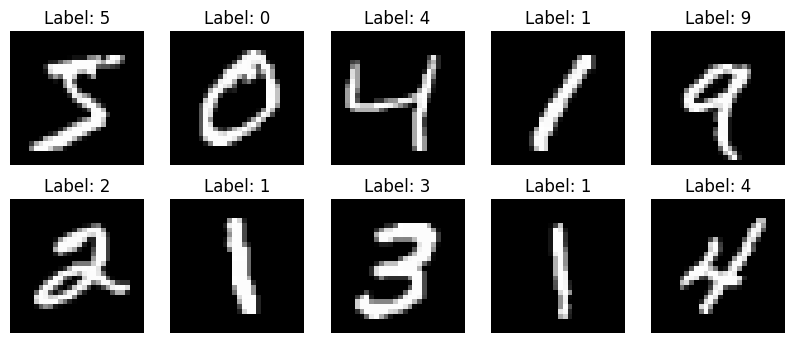

In [85]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# Data Preprocessing for FNN Model

In [86]:
# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [87]:
# Each image (28x28) is flattened into a vector of size 784.
x_train_fnn = x_train.reshape(-1, 784)
x_test_fnn = x_test.reshape(-1, 784)

# Check the new shape of the flattened data
print(f"FNN Training Shape: {x_train_fnn.shape}")
print(f"FNN Test Shape: {x_test_fnn.shape}")

FNN Training Shape: (60000, 784)
FNN Test Shape: (10000, 784)


# Building the FNN Model

In [95]:
def create_fnn_model(neurons_layer1=128, neurons_layer2=64, optimizer='adam'):
    model = Sequential([
        Input(shape=(784,)),
        Dense(neurons_layer1, activation='relu'),
        Dense(neurons_layer2, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [97]:
# 1. Wrap the model for Scikit-Learn
model_wrapper = KerasClassifier(model=create_fnn_model, verbose=0)

# 2. Define the grid of hyperparameters to explore
param_grid = {
    'model__neurons_layer1': [64, 128],
    'model__neurons_layer2': [32, 64],
    'optimizer': ['adam', 'sgd'],
    'batch_size': [32, 64],
    'epochs': [5] # Keep epochs low for the search phase
}

# 3. Setup GridSearchCV with 3-fold cross-validation
grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3, n_jobs=-1)

# 4. Run search on a subset of the training data (e.g., 5000 samples)
print("Starting Grid Search...")
grid_result = grid.fit(x_train_fnn[:5000], y_train[:5000])

print(f"Best Parameters: {grid_result.best_params_}")

Starting Grid Search...
Best Parameters: {'batch_size': 32, 'epochs': 5, 'model__neurons_layer1': 128, 'model__neurons_layer2': 64, 'optimizer': 'sgd'}


In [98]:
# Extract the best parameters from your grid search results
best_params = grid_result.best_params_

# Build the final fnn_model using these optimized values
fnn_model = create_fnn_model(
    neurons_layer1=best_params['model__neurons_layer1'],
    neurons_layer2=best_params['model__neurons_layer2'],
    optimizer=best_params['optimizer']
)

In [99]:
# Training the FNN model using the full training data
print("Starting Final FNN Training with Optimized Parameters...")
history_fnn = fnn_model.fit(
    x_train_fnn, y_train,
    epochs=10,             # Increasing epochs to 10 for final convergence
    batch_size=best_params['batch_size'],
    validation_split=0.1
)

Starting Final FNN Training with Optimized Parameters...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - accuracy: 0.8215 - loss: 0.6815 - val_accuracy: 0.9193 - val_loss: 0.2892
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.9111 - loss: 0.3091 - val_accuracy: 0.9395 - val_loss: 0.2221
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.9276 - loss: 0.2542 - val_accuracy: 0.9463 - val_loss: 0.1875
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - accuracy: 0.9366 - loss: 0.2192 - val_accuracy: 0.9548 - val_loss: 0.1686
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.9440 - loss: 0.1934 - val_accuracy: 0.9597 - val_loss: 0.1471
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.9499 - loss: 0.1725 - val_accuracy: 0.9587 - val_loss: 0.1444
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.9557 - loss: 0.1549 - val_accuracy: 0.9657 - val_loss: 0.1254
Epoch 8/10
1688/168

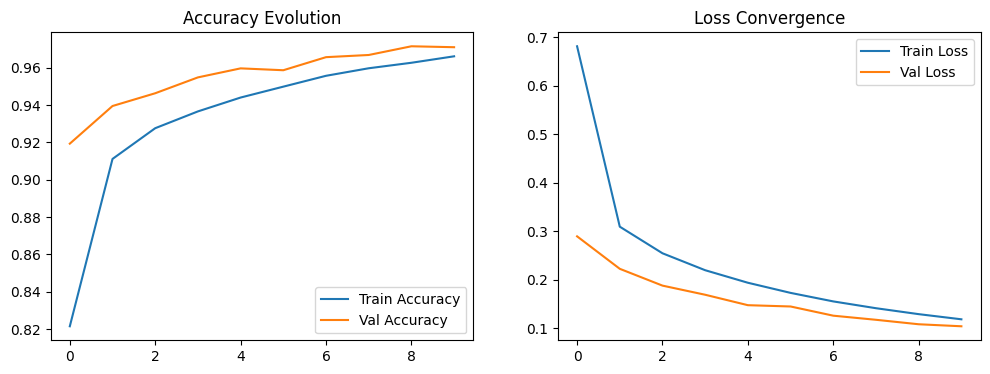

In [100]:

# Proof that 10 epochs and our architecture was correct
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_fnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_fnn.history['loss'], label='Train Loss')
plt.plot(history_fnn.history['val_loss'], label='Val Loss')
plt.title('Loss Convergence')
plt.legend()

plt.show()

# Testing Model without adding Noise on Test Dataset

In [101]:
# Evaluate the model on the clean test dataset
test_loss_fnn, test_acc_fnn = fnn_model.evaluate(x_test_fnn, y_test)


# Display the accuracy result
print("FNN Test Accuracy:", test_acc_fnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9627 - loss: 0.1213
FNN Test Accuracy: 0.9627000093460083


# Adding Impulsive Noise

In [102]:
def add_impulsive_noise(image, noise_factor=0.1):
    """
    Add impulsive noise to an image.
    Parameters:
        - image: The image (2D or 3D array) to add noise to.
        - noise_factor: Proportion of image pixels to modify.
    """
    np.random.seed(42)

    noisy_image = image.copy()

    #set some pixels to 1
    white_pixels = np.random.rand(*image.shape) < (noise_factor / 2)
    noisy_image[white_pixels] = 1

    # set some pixels to 0
    black_pixels = np.random.rand(*image.shape) < (noise_factor / 2)

    noisy_image[black_pixels] = 0

    return noisy_image


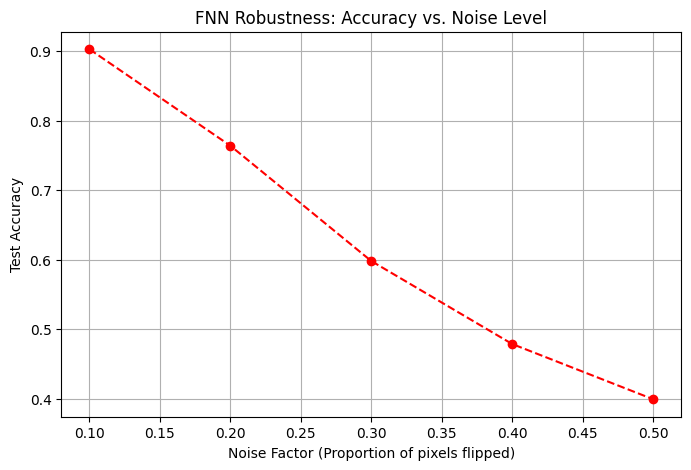

In [103]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
accuracies = []

for level in noise_levels:
    # Generate noise on the 2D test set
    x_test_temp = add_impulsive_noise(x_test_2d, noise_factor=level)
    # Flatten for FNN
    x_test_temp_fnn = x_test_temp.reshape(-1, 784)
    # Evaluate
    _, acc = fnn_model.evaluate(x_test_temp_fnn[:2000], subset_labels, verbose=0)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, accuracies, marker='o', linestyle='--', color='red')
plt.title('FNN Robustness: Accuracy vs. Noise Level')
plt.xlabel('Noise Factor (Proportion of pixels flipped)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

In [104]:
# 1. Reset x_test to 2D images because the noise function needs (28, 28) shape
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()
x_test_2d = x_test_raw.astype("float32") / 255.0 

# 2. Make a noisy version of the 2D images
x_test_noisy_2d = add_impulsive_noise(x_test_2d, noise_factor=0.1)

# 3. Flatten both clean and noisy images into 1D vectors for the FNN
x_test_clean_fnn = x_test_2d.reshape(-1, 784)
x_test_noisy_fnn = x_test_noisy_2d.reshape(-1, 784)

# 4. Grab the first 2000 images for our testing subset
clean_subset_images = x_test_clean_fnn[:2000]
noisy_subset_images = x_test_noisy_fnn[:2000]
subset_labels = y_test_raw[:2000]

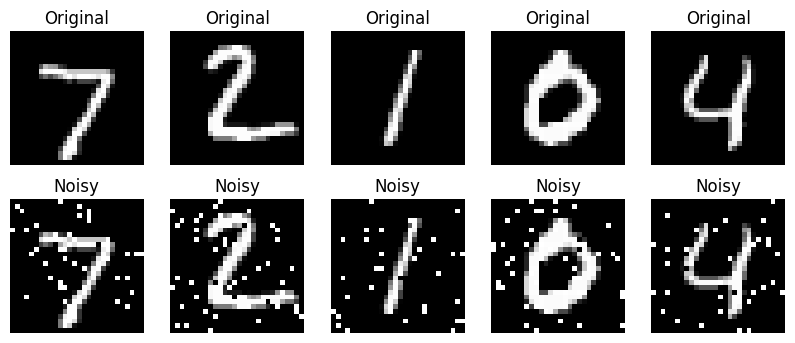

In [105]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy") 
    plt.axis('off')

plt.show()

# Testing model on Dataset with Noise

In [106]:
# 1. Evaluate Clean
clean_loss, clean_acc = fnn_model.evaluate(clean_subset_images, subset_labels, verbose=0)
print(f"FNN Clean Accuracy: {clean_acc:.4f}")

# 2. Evaluate Noisy
noisy_loss, noisy_acc = fnn_model.evaluate(noisy_subset_images, subset_labels, verbose=0)
print(f"FNN Noisy Accuracy: {noisy_acc:.4f}")

# 3. Accuracy Drop
print(f"Accuracy Drop: {clean_acc - noisy_acc:.4f}")

FNN Clean Accuracy: 0.9515
FNN Noisy Accuracy: 0.9030
Accuracy Drop: 0.0485


## Model Comparison & Final Conclusion

**Results:**
* FNN (Optimized via Grid Search): 95.15% (Clean Subset) | 90.30% (Noisy Subset)
* CNN (Optimized via Grid Search): 98.90% (Clean Subset) | 88.85% (Noisy Subset)

**Conclusion:**
The CNN outperformed the FNN on the original, clean dataset, achieving a superior subset accuracy of 98.90% compared to 95.15% for the FNN. This is because the FNN flattens 2D images into 1D vectors, which destroys the spatial relationships between pixels. In contrast, the CNN preserves the 2D structure of the image. Its convolutional and pooling layers act as feature extractors that recognize local spatial patterns, such as edges and curves, making the CNN significantly more accurate on standard data.

While the CNN’s specialized feature extraction leads to higher overall test accuracy (99.21% vs 96.27%), it proved more sensitive to impulsive noise in this experiment, showing a 10.05% drop in accuracy compared to the FNN's 4.85% drop. This suggests that the global connectivity of an optimized FNN can sometimes offer more resilience to pixel-level distortions, even though the CNN remains the superior model for general image recognition.